In [18]:
# 1. IMPORT LIBRARIES
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set(style="whitegrid")

In [19]:
import pandas as pd

df = pd.read_csv(r"C:\health-insurance-analysis\data\health_insurance_cost_and_risk_dataset.csv")

df.head()

,age,sex,bmi,children,smoker,region,charges,blood_pressure,exercise_frequency,pre_existing_condition,occupation_risk,annual_income
0,19.0,female,27.900,0.0,yes,southwest,16884.92400,139.0,Never,True,high,104158.67
1,18.0,male,33.770,1.0,no,southeast,1725.55230,129.9,Weekly,True,moderate,43530.88
2,28.0,male,33.000,3.0,no,southeast,4449.46200,111.1,Rarely,False,high,113004.75
3,33.0,male,22.705,0.0,no,northwest,21984.47061,126.9,Rarely,False,high,185041.26
4,32.0,male,28.880,0.0,no,northwest,3866.85520,134.7,Rarely,True,low,46747.97


In [20]:
# 3. BASIC INFO
df.info()
df.describe()

<class 'pandas.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 12 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   age                     1337 non-null   float64
 1   sex                     1338 non-null   str    
 2   bmi                     1337 non-null   float64
 3   children                1337 non-null   float64
 4   smoker                  1338 non-null   str    
 5   region                  1338 non-null   str    
 6   charges                 1338 non-null   float64
 7   blood_pressure          1338 non-null   float64
 8   exercise_frequency      1338 non-null   str    
 9   pre_existing_condition  1338 non-null   bool   
 10  occupation_risk         1338 non-null   str    
 11  annual_income           1338 non-null   float64
dtypes: bool(1), float64(6), str(5)
memory usage: 116.4 KB


,age,bmi,children,charges,blood_pressure,annual_income
count,1337.000000,1337.000000,1337.000000,1338.000000,1338.000000,1338.000000
mean,39.219147,30.664589,1.095737,13270.422265,124.452840,114318.670187
std,14.048217,6.100313,1.205571,12110.011237,8.544297,49654.737363
min,18.000000,15.960000,0.000000,1121.873900,110.100000,30109.230000
25%,27.000000,26.290000,0.000000,4740.287150,117.425000,70928.752500
50%,39.000000,30.400000,1.000000,9382.033000,124.550000,114222.370000
75%,51.000000,34.700000,2.000000,16639.912515,131.400000,157131.387500
max,64.000000,53.130000,5.000000,63770.428010,140.000000,199966.140000


In [21]:
# 4. MISSING VALUES
df.isnull().sum()

age                       1
sex                       0
bmi                       1
children                  1
smoker                    0
region                    0
charges                   0
blood_pressure            0
exercise_frequency        0
pre_existing_condition    0
occupation_risk           0
annual_income             0
dtype: int64

In [23]:
# ==============================
# FIXED DATA CLEANING (NO ERRORS)
# ==============================

# Fill missing values (NO inplace)
df['age'] = df['age'].fillna(df['age'].mean())
df['bmi'] = df['bmi'].fillna(df['bmi'].median())
df['children'] = df['children'].fillna(df['children'].mode()[0])

# Remove duplicates
df = df.drop_duplicates()

# Convert safely to integer
df['children'] = df['children'].astype('int64')

In [24]:
# 6. DATA PREPROCESSING
# Clean text
df['exercise_frequency'] = df['exercise_frequency'].str.strip().str.capitalize()
df['occupation_risk'] = df['occupation_risk'].str.strip().str.lower()
df['smoker'] = df['smoker'].str.strip().str.lower()

# Encoding
df['sex'] = df['sex'].map({'male':0, 'female':1})
df['smoker'] = df['smoker'].map({'no':0, 'yes':1})

df['exercise_frequency'] = df['exercise_frequency'].map({
    'Never':0,
    'Rarely':1,
    'Weekly':2
})

df['occupation_risk'] = df['occupation_risk'].map({
    'low':0,
    'moderate':1,
    'high':2
})

df['pre_existing_condition'] = df['pre_existing_condition'].astype(int)

# One-hot encoding
df = pd.get_dummies(df, columns=['region'], drop_first=True)

In [25]:
# 7. FEATURE ENGINEERING
df['bmi_category'] = pd.cut(df['bmi'],
                           bins=[0,18.5,25,30,100],
                           labels=[0,1,2,3]).astype(int)

df['age_group'] = pd.cut(df['age'],
                        bins=[0,18,35,60,100],
                        labels=[0,1,2,3]).astype(int)

df['risk_score'] = df['age'] * df['bmi'] / 100

df['lifestyle_index'] = df['exercise_frequency'] * (1 - df['smoker'])

df['family_size'] = df['children'] + 1

df['bmi_smoker'] = df['bmi'] * df['smoker']
df['age_smoker'] = df['age'] * df['smoker']

df['income_level'] = pd.cut(df['annual_income'],
                           bins=[0,50000,100000,200000,500000],
                           labels=[0,1,2,3]).astype(int)

In [26]:
# 8. CHECK SHAPE
print("Final Shape:", df.shape)

Final Shape: (1338, 22)


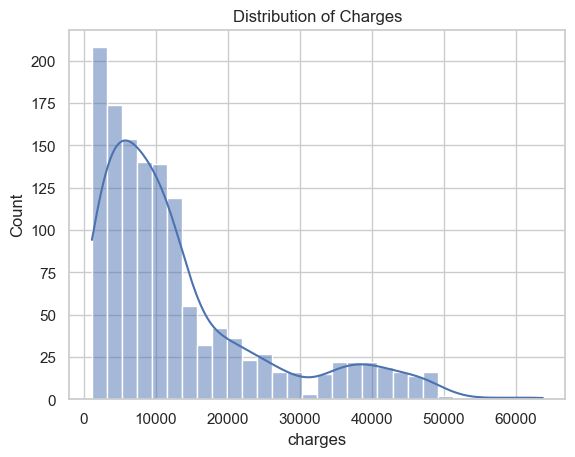

In [27]:
# 9. VISUALIZATION
sns.histplot(df['charges'], kde=True)
plt.title("Distribution of Charges")
plt.show()

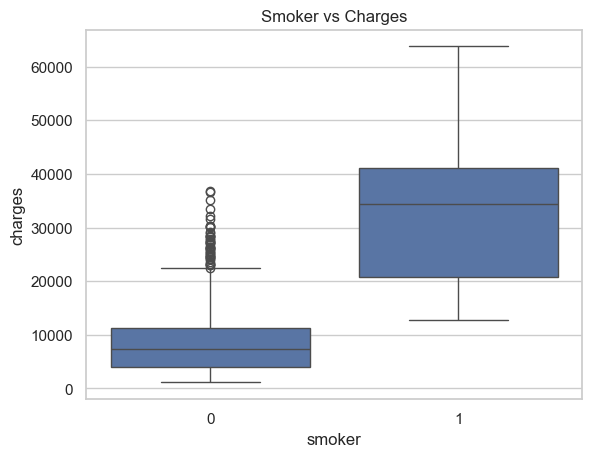

In [28]:
sns.boxplot(x=df['smoker'], y=df['charges'])
plt.title("Smoker vs Charges")
plt.show()

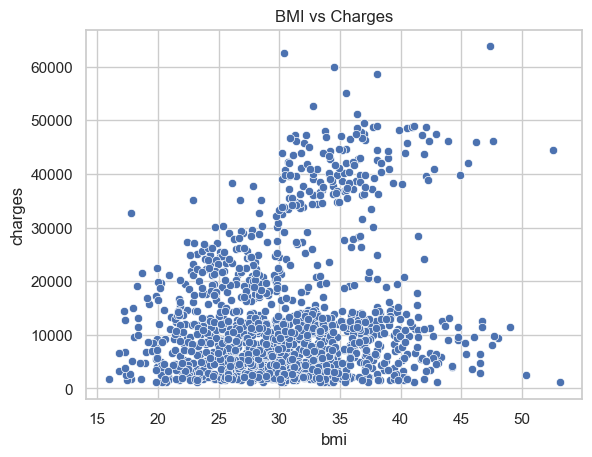

In [29]:
sns.scatterplot(x=df['bmi'], y=df['charges'])
plt.title("BMI vs Charges")
plt.show()


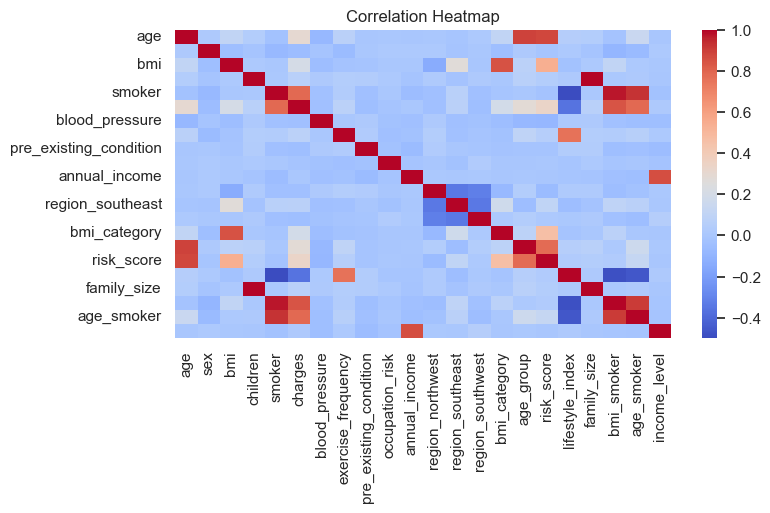

In [35]:
plt.figure(figsize=(8,4))
sns.heatmap(df.corr(), cmap="coolwarm")
plt.title("Correlation Heatmap")
plt.show()

In [36]:
# 10. SAVE CLEANED DATA
df.to_csv(r"C:\health-insurance-analysis\data\cleaned_insurance_data.csv", index=False)

In [38]:
#11. MACHINE LEARNING
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, r2_score

X = df.drop('charges', axis=1)
y = df['charges']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

model = LinearRegression()
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

print("MAE:", mean_absolute_error(y_test, y_pred))
print("R2 Score:", r2_score(y_test, y_pred))

ValueError: Input X contains NaN.
LinearRegression does not accept missing values encoded as NaN natively. For supervised learning, you might want to consider sklearn.ensemble.HistGradientBoostingClassifier and Regressor which accept missing values encoded as NaNs natively. Alternatively, it is possible to preprocess the data, for instance by using an imputer transformer in a pipeline or drop samples with missing values. See https://scikit-learn.org/stable/modules/impute.html You can find a list of all estimators that handle NaN values at the following page: https://scikit-learn.org/stable/modules/impute.html#estimators-that-handle-nan-values